In [58]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import Sequential
from tensorflow.keras.activations import sigmoid
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt
import seaborn as sns


In [59]:
curr_dir = os.getcwd()
print(curr_dir)

c:\Users\Admin\ML-concepts\NeuralNetwork


In [60]:
for root,dirs,files in os.walk(curr_dir):
    for dir in dirs:
        print(files)
        if dir.startswith('datasets'):
            dataset_path = os.path.join(root,dir)
        for file in os.listdir(dataset_path):
            if file.startswith('Coffee'):
                file_path = os.path.join(dataset_path,file)
                file_size = os.path.getsize(file_path)
                if file_size == 0:
                    continue
                try:
                    dataset = pd.read_csv(file_path)
                except Exception as e:
                    print(e)


['coffe_roasting_dataset.ipynb', 'Dot.jpg', 'image_pixel.ipynb', 'Neurons_layers.ipynb']


In [61]:
dataset.head()

,Temprature,Duration,Target
0,185.32,12.69,1
1,259.92,11.87,0
2,231.01,14.41,0
3,175.37,11.72,0
4,187.12,14.13,1


In [62]:
X = dataset.iloc[:,:2]
y = dataset.iloc[:,-1]


In [63]:
X.shape
y.shape

(200,)

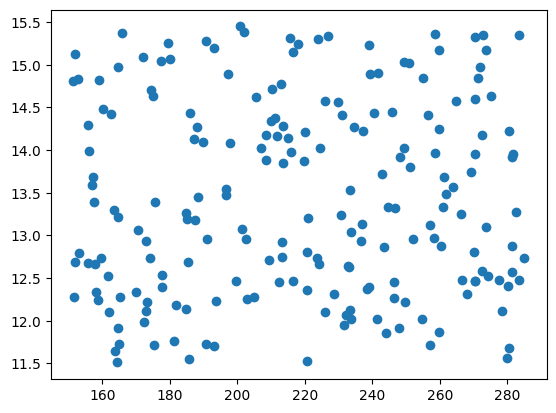

In [64]:
plt.scatter(X.iloc[:,0],X.iloc[:,1],marker='o')

In [65]:
print(X.describe)
print(X.min())
print(X.max())

<bound method NDFrame.describe of      Temprature  Duration
0        185.32     12.69
1        259.92     11.87
2        231.01     14.41
3        175.37     11.72
4        187.12     14.13
..          ...       ...
195      223.78     15.30
196      266.63     12.48
197      273.68     13.10
198      220.61     12.80
199      284.99     12.73

[200 rows x 2 columns]>
Temprature    151.32
Duration       11.51
dtype: float64
Temprature    284.99
Duration       15.45
dtype: float64


### Normalize Data
Fitting the weights to the data (back-propagation, covered in next week's lectures) will proceed more quickly if the data is normalized. 
The procedure below uses a Keras [normalization layer](https://keras.io/api/layers/preprocessing_layers/numerical/normalization/). It has the following steps:
- create a "Normalization Layer". Note, as applied here, this is not a layer in your model.
- 'adapt' the data. This learns the mean and variance of the data set and saves the values internally.
- normalize the data.  
It is important to apply normalization to any future data that utilizes the learned model.

In [66]:
norm_l = tf.keras.layers.Normalization(axis=-1)

norm_l.adapt(X.to_numpy())

Xn = norm_l(X)

In [69]:
X.to_numpy()
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")

InvalidIndexError: (slice(None, None, None), 0)

In [70]:
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


In [71]:
Xt = np.tile(Xn,(1000,1))
Yt= np.tile(y,(1000,1))   
print(Xt.shape, Yt.shape)  

(200000, 2) (1000, 200)


## **TF model**

In [72]:
tf.random.set_seed(42)
model = Sequential(
    [   tf.keras.Input(shape=(2,)), # This is the shape of input parameter
        Dense(units=3,activation='sigmoid',name='layer1'),
        Dense(units=1,activation='sigmoid',name='layer2')

    ]
)

**tf.keras.Input(shape=(2,))**

Shape of input parameter, without batch dimension

- it means 1 sample is actually (temperature,duration)

- I read it as " every sample has 2 features"

But for a batch dimension it would look like:

[

    [t1,d1],

    [t2,d2],

    [t3,d3]
    
]

shape of (m,2)

In [86]:
x = np.array([[1,2],])
x

array([[1, 2]])

In [74]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

>**Note 1:** The `tf.keras.Input(shape=(2,)),` specifies the expected shape of the input. This allows Tensorflow to size the weights and bias parameters at this point.  This is useful when exploring Tensorflow models. This statement can be omitted in practice and Tensorflow will size the network parameters when the input data is specified in the `model.fit` statement.  
>**Note 2:** Including the sigmoid activation in the final layer is not considered best practice. It would instead be accounted for in the loss which improves numerical stability. This will be described in more detail in a later lab.

The `model.summary()` provides a description of the network:

In [75]:
L1_num_params = 2 * 3 + 3   # W1 parameters  + b1 parameters
L2_num_params = 3 * 1 + 1   # W2 parameters  + b2 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params  )

L1 params =  9 , L2 params =  4


In [76]:
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[ 0.97624683  0.70798075 -0.37104666]
 [ 1.0728917  -0.780393    0.60560036]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[-0.9225066 ]
 [-0.48808682]
 [-0.7058067 ]] 
b2(1,): [0.]


- The `model.compile` statement defines a loss function and specifies a compile optimization.
- The `model.fit` statement runs gradient descent and fits the weights to the data.

In [ ]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
)

model.fit(
    Xt,Yt,            
    epochs=10,
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5213  
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5206 
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5206 
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5207 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5208 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5209 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5209 
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5209 
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5208 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5208 


#### Epochs and batches
In the `fit` statement above, the number of `epochs` was set to 10. This specifies that the entire data set should be applied during training 10 times.  During training, you see output describing the progress of training that looks like this:
```
Epoch 1/10
6250/6250 [==============================] - 6s 910us/step - loss: 0.1782
```
The first line, `Epoch 1/10`, describes which epoch the model is currently running. For efficiency, the training data set is broken into 'batches'. The default size of a batch in Tensorflow is 32. There are 200000 examples in our expanded data set or 6250 batches. The notation on the 2nd line `6250/6250 [====` is describing which batch has been executed.

#### Weights have been updated:

In [78]:
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[ 0.97624683  0.70798075 -0.37104666]
 [ 1.0728917  -0.780393    0.60560036]] 
b1: [0.0000000e+00 0.0000000e+00 8.4010035e-18]
W2:
 [[-0.90325266]
 [-0.46883297]
 [-0.7058067 ]] 
b2: [0.01925403]


You can see that the values are different from what you printed before calling `model.fit()`. With these, the model should be able to discern what is a good or bad coffee roast.

For the purpose of the next discussion, instead of using the weights you got right away, you will first set some weights we saved from a previous training run. This is so that this notebook remains robust to changes in Tensorflow over time. Different training runs can produce somewhat different results and the following discussion applies when the model has the weights you will load below. 

Feel free to re-run the notebook later with the cell below commented out to see if there is any difference. If you got a low loss after the training above (e.g. 0.002), then you will most likely get the same results.

In [79]:
# After finishing the lab later, you can re-run all 
# cells except this one to see if your trained model
# gets the same results.

# Set weights from a previous run. 
W1 = np.array([
    [-8.94,  0.29, 12.89],
    [-0.17, -7.34, 10.79]] )
b1 = np.array([-9.87, -9.28,  1.01])
W2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])

# Replace the weights from your trained model with
# the values above.
model.get_layer("layer1").set_weights([W1,b1])
model.get_layer("layer2").set_weights([W2,b2])

In [80]:
# Check if the weights are successfully replaced
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[-8.94  0.29 12.89]
 [-0.17 -7.34 10.79]] 
b1: [-9.87 -9.28  1.01]
W2:
 [[-31.38]
 [-27.86]
 [-32.79]] 
b2: [15.54]


#### Model **prediction**

Let's start by creating input data. The model is expecting one or more examples where examples are in the rows of matrix. In this case, we have two features so the matrix will be (m,2) where m is the number of examples.
Recall, we have normalized the input features so we must normalize our test data as well.   
To make a prediction, you apply the `predict` method.

In [81]:
X_test = np.array([
    [200,13.9],  # positive example
    [200,17]])   # negative example
X_testn = norm_l(X_test)
predictions = model.predict(X_testn)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
predictions = 
 [[9.6203965e-01]
 [3.0316290e-08]]


Applying threshold to convert probabilities:

In [ ]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions = \n{yhat}")

[[1.]
 [0.]]
decisions = 
[[1.]
 [0.]]


In [84]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]
